In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = 12   # if monthly --> 12, else if daily --> 24
FEATURES = 5
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 25 x 12 x 5


In [3]:
df = pd.read_csv("datasets/m4/Monthly-train.csv")
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V2786,V2787,V2788,V2789,V2790,V2791,V2792,V2793,V2794,V2795
0,M1,8000.0,8350.0,8570.0,7700.0,7080.0,6520.0,6070.0,6650.0,6830.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M2,2440.0,2490.0,2710.0,2290.0,1960.0,1990.0,1960.0,2530.0,2640.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M3,2670.0,2590.0,2784.0,2816.0,2888.0,2906.0,2839.0,2860.0,2798.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M4,7264.0,7215.0,7022.0,7040.0,6966.0,6984.0,7025.0,7082.0,6956.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M5,4210.0,4290.0,4250.0,4320.0,4320.0,4330.0,4320.0,4260.0,4220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# make dataframe for selected series
df_selected = df.iloc[13:18,1:PERIOD*TIME+1]
df_selected.shape,df_selected.head()

((5, 300),
         V2      V3      V4      V5      V6      V7      V8      V9     V10  \
 13  1159.0  1156.0  1156.0  1164.0  1174.0  1169.0  1135.0  1135.0  1174.0   
 14   843.4   837.1   834.9   843.9   849.5   866.9   880.4   892.8   881.0   
 15  3537.0  3532.0  3556.0  3564.0  3585.0  3559.0  3400.0  3362.0  3579.0   
 16  1769.4  1786.6  1799.7  1797.1  1794.7  1737.4  1530.1  1504.9  1741.0   
 17  1767.6  1745.4  1756.3  1766.9  1790.3  1821.6  1869.9  1857.1  1838.0   
 
        V11  ...    V292    V293    V294    V295    V296    V297    V298  \
 13  1199.0  ...  3607.0  3599.0  3564.0  3442.0  3368.0  3375.0  3512.0   
 14   865.6  ...  2134.9  2137.4  2144.3  2192.8  2206.2  2213.5  2176.7   
 15  3671.0  ...  9755.0  9787.0  9839.0  9836.0  9182.0  9087.0  9424.0   
 16  1832.1  ...  5201.9  5224.0  5235.6  5069.6  4244.7  4204.7  4756.4   
 17  1838.9  ...  4553.1  4563.0  4603.4  4766.4  4937.3  4882.3  4667.6   
 
       V299    V300    V301  
 13  3639.0  3681.0  3646

In [5]:
# period_count = 25
# period_length = 12
# for i in range(len(df_selected)):
#     ts_1 = df_selected.iloc[i][1:]
#     ts_1_cleaned = ts_1.dropna().astype(float)
#     print(ts_1.shape, ts_1_cleaned.shape)

#     plt.figure(figsize=(12, 6))
#     plt.plot(ts_1_cleaned[:period_length*period_count])
#     for d in range(1, period_count):
#         plt.axvline(d * period_length, color='r', ls=':', lw=0.5)

In [6]:
df = df_selected.T
df.columns.to_list()

[13, 14, 15, 16, 17]

(300,)
(300,)
(300,)
(300,)
(300,)


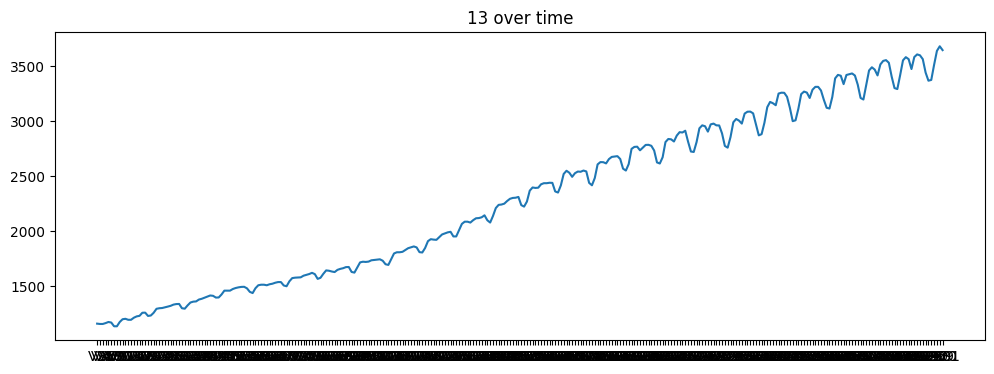

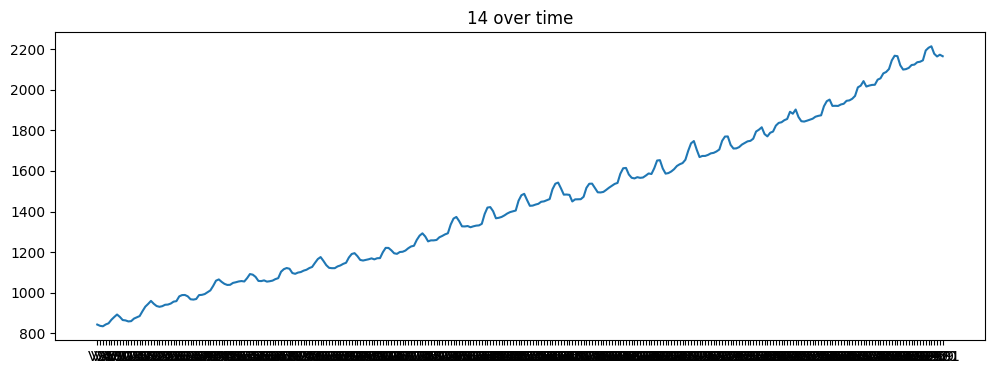

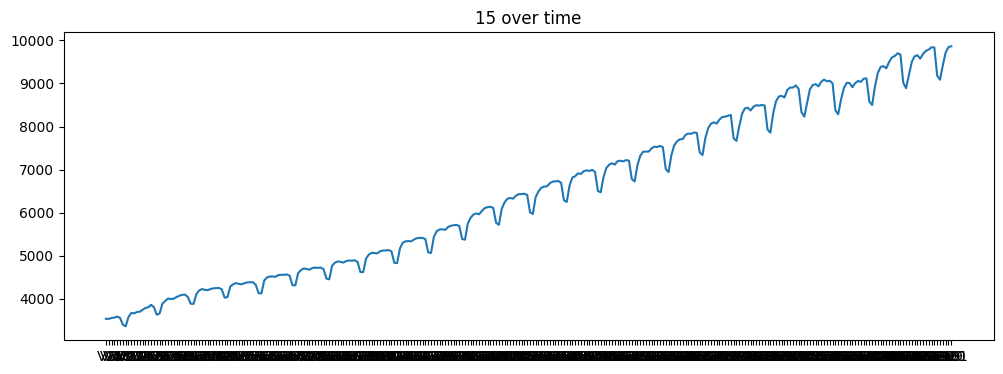

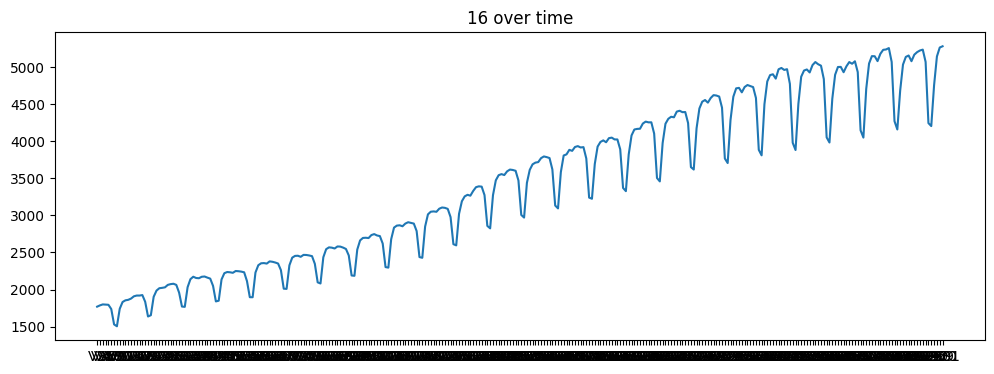

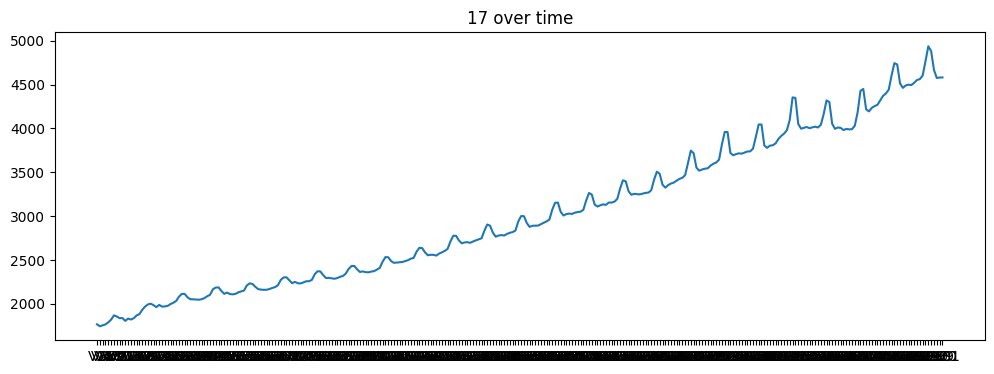

In [7]:
for col in df.columns.to_list():
    print(df[col].shape)
    plt.figure(figsize=(12, 4))
    plt.plot(df[col])
    plt.title(f"{col} over time")

### Smoothing using rolling mean

In [8]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in df.columns:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col])
#     plt.title(f"{col} over time (smoothed)")

In [9]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[ df.columns.to_list()][:PERIOD*TIME].values

tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(25, 12, 5)

In [10]:
25*12*5

1500

In [11]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 12, 5)
Test tensor shape: (5, 12, 5)


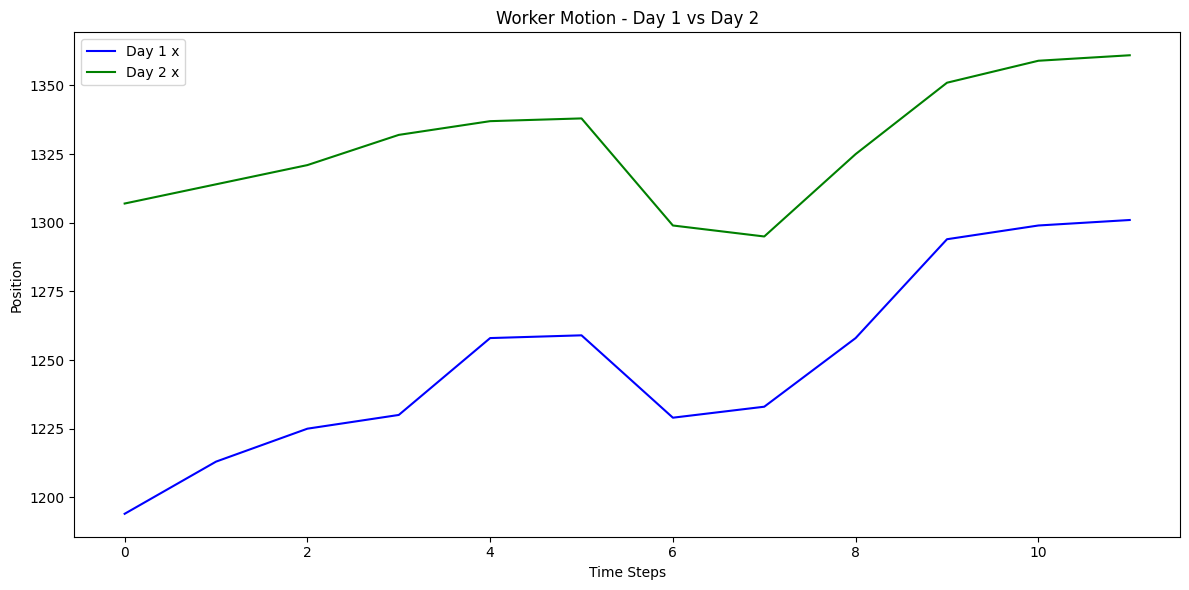

In [12]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [13]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (12, 2)
Feature factors shape: (5, 2)


In [14]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 12, 5)
Reconstructed tensor shape: (20, 12, 5)


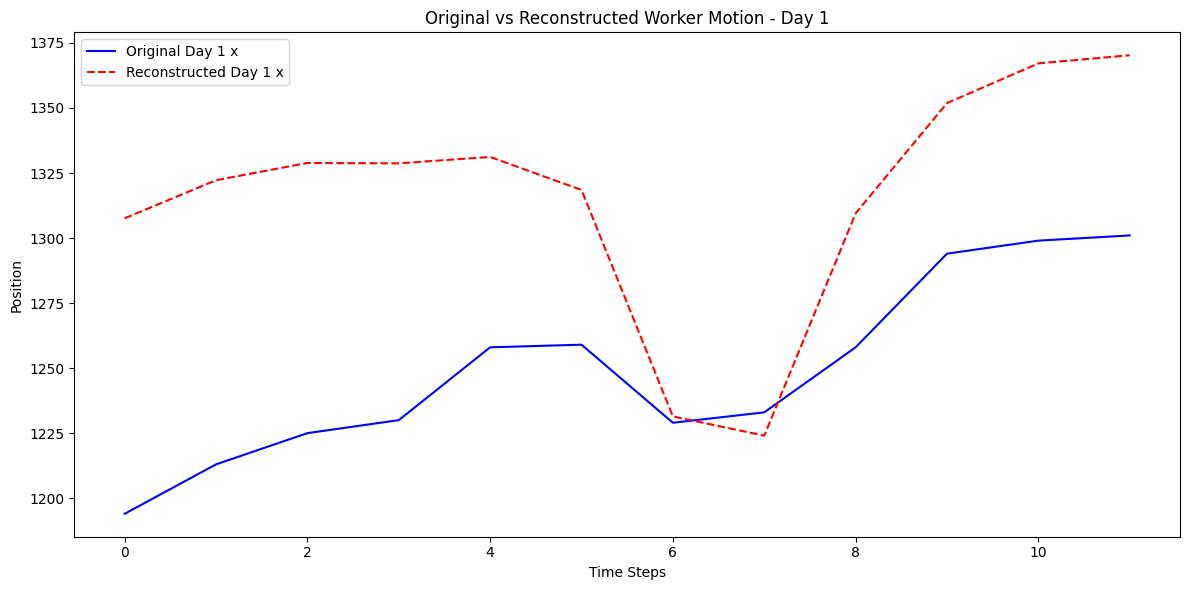

In [15]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [16]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

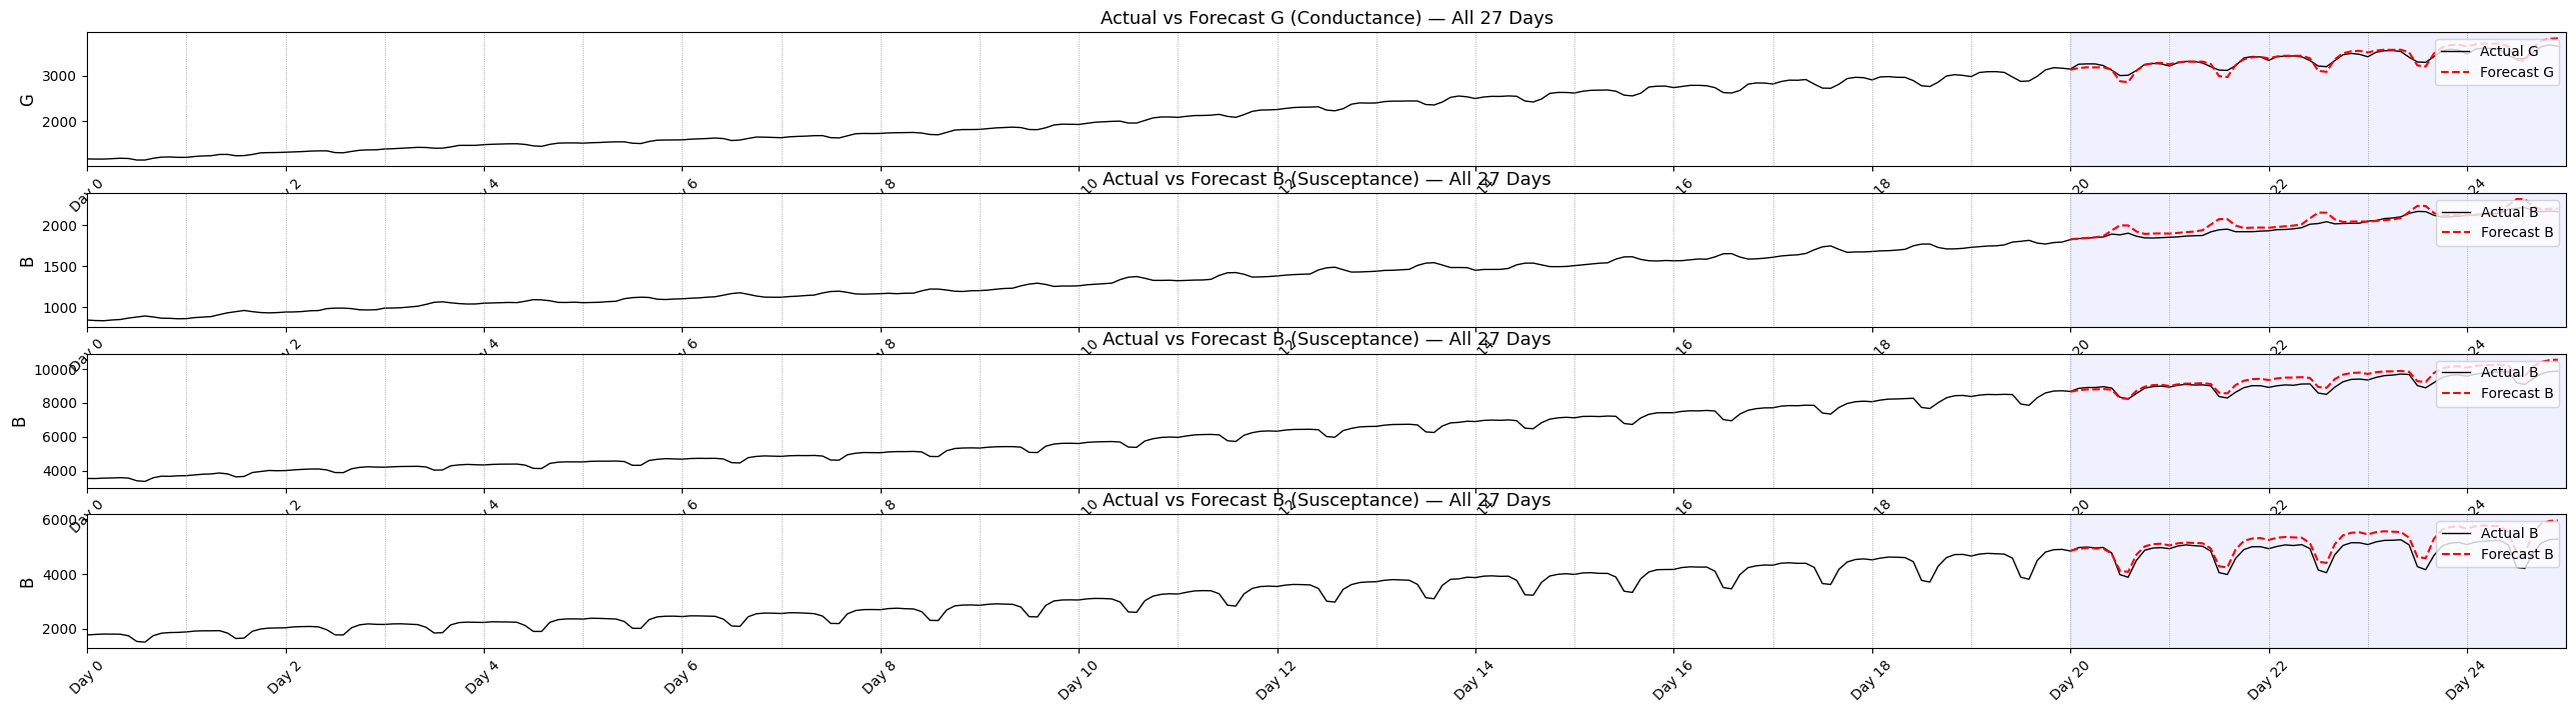

In [18]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

plt.figure(figsize=(32, 8))

plt.subplot(4, 1, 1)
plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('G', fontsize=12)
plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 2)
plt.plot(x, full_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 3)
plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 4)
plt.plot(x, full_series[:, 3], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 3], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

# plt.xlabel('Time Steps', fontsize=12)
# plt.tight_layout()
# plt.show()

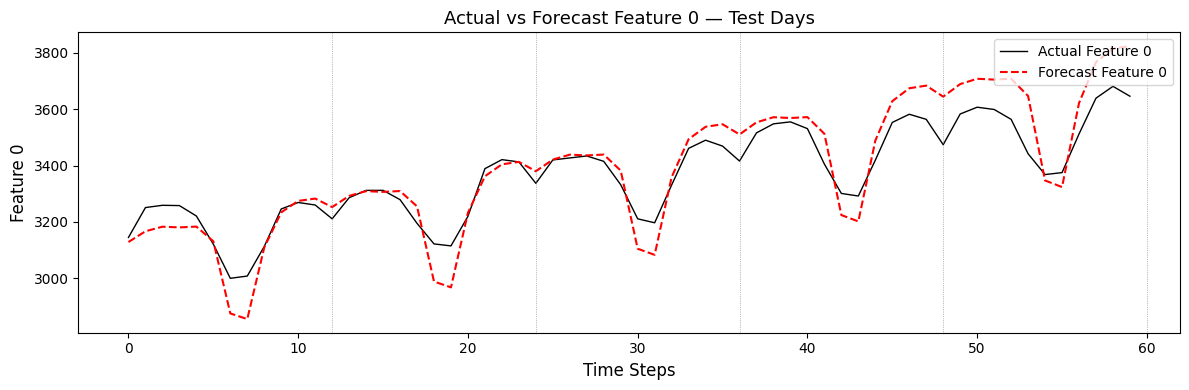

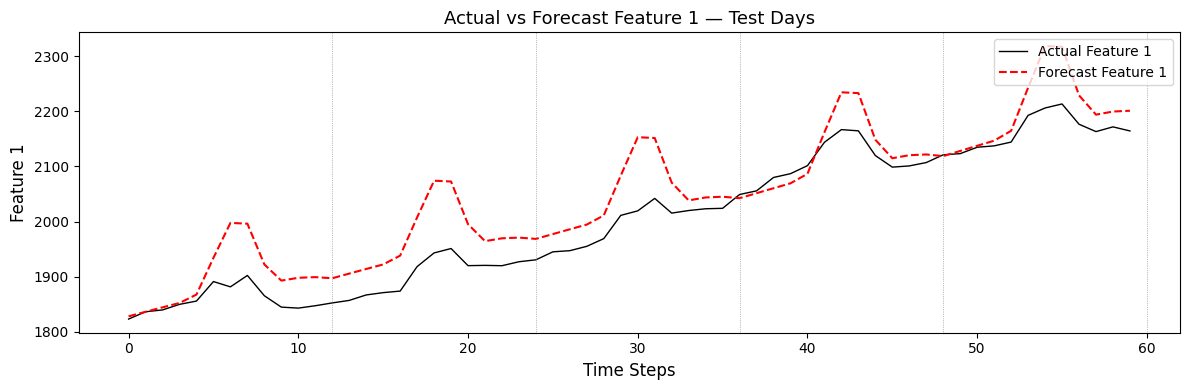

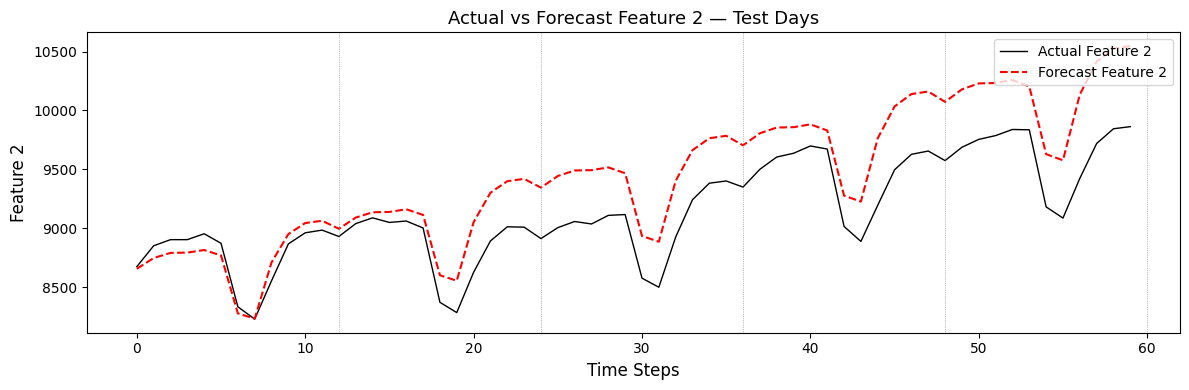

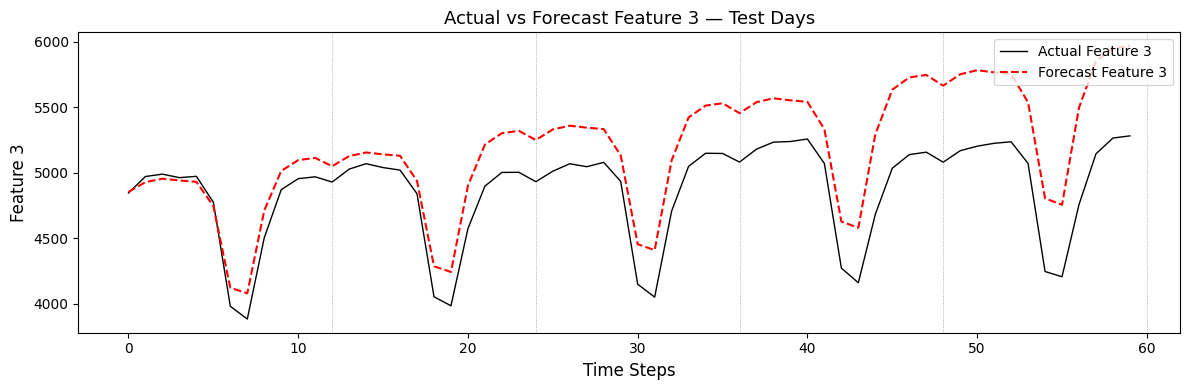

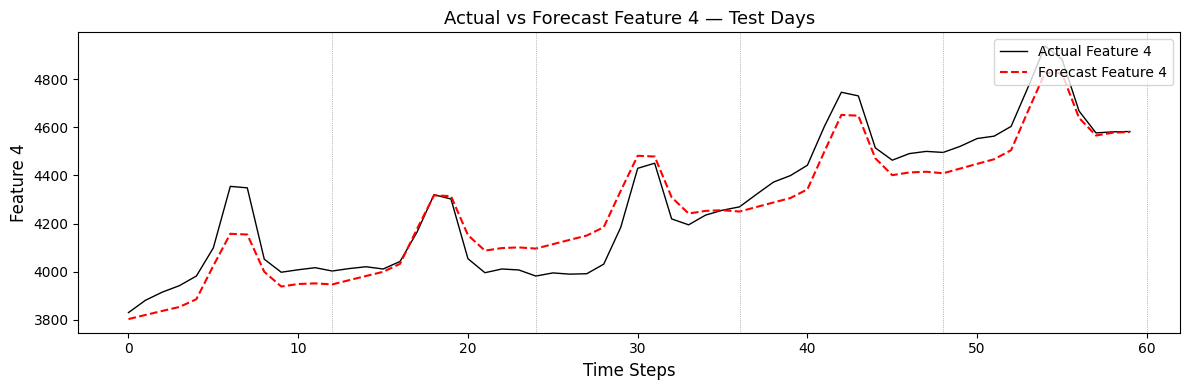

In [23]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [20]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((240, 5), (60, 5))

In [27]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

Feature 0 R²: 0.7352, MSE: 7061.2415, MAE: 65.6455, RMSE: 84.0312
Feature 1 R²: 0.7811, MSE: 3205.2581, MAE: 44.5417, RMSE: 56.6150
Feature 2 R²: 0.2398, MSE: 137836.6269, MAE: 319.4695, RMSE: 371.2636
Feature 3 R²: -0.0116, MSE: 146374.3512, MAE: 327.7369, RMSE: 382.5890
Feature 4 R²: 0.9051, MSE: 7423.8331, MAE: 72.9614, RMSE: 86.1617
